<a href="https://colab.research.google.com/github/Raffikusuma/VisualisaiSuperstoreDataset/blob/main/2318009_Raffi_Visualisasi_Data_Superstore_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [7]:
from google.colab import drive
drive.mount('/content/drive')

dataset_path = '/content/drive/MyDrive/Bisnis Intelegen/UTS BI/Sample - Superstore.csv'

Mounted at /content/drive


# 1. Load Dataset

In [11]:
df = pd.read_csv(dataset_path, encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Cek Struktur Data

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

# Cek Missing Value

In [13]:
df.isnull().sum()
df = df.dropna()

# Ubah Format Tanggal

In [14]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Tambahkan Kolom Waktu

In [15]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.to_period('M')
df['Day'] = df['Order Date'].dt.day

# Cek Tipe Data Numerik

In [16]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Year,Day
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896,2015.722233,15.468481
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,2014.000000,1.000000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,2015.000000,8.000000
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,2016.000000,15.000000
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,2017.000000,23.000000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,2017.000000,31.000000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,1.123555,8.748327


# Sorting Data

In [18]:
df = df.sort_values(by='Order Date')

# Line Chart — Trend Penjualan

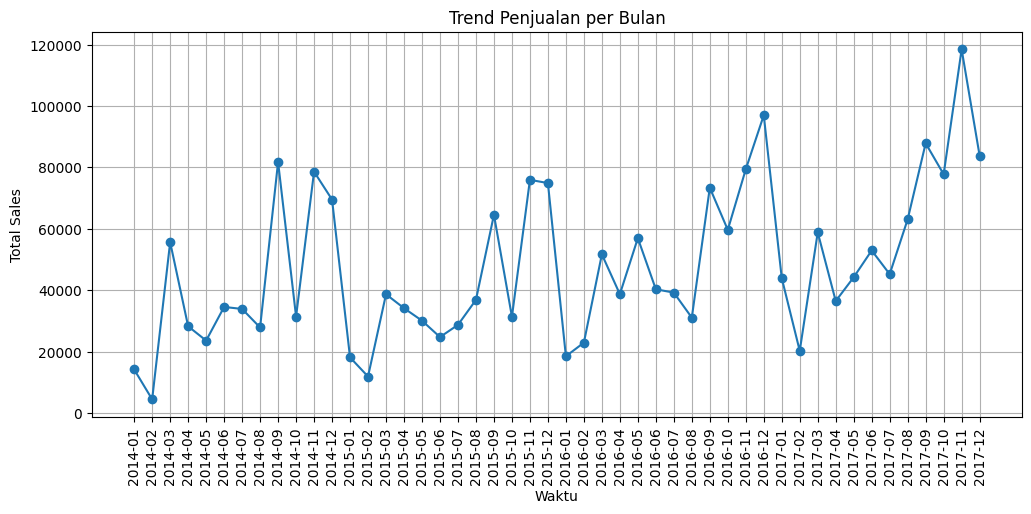

In [19]:
# grouping per bulan
sales_trend = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().reset_index()

# ubah ke string biar rapi di plot
sales_trend['Order Date'] = sales_trend['Order Date'].astype(str)

plt.figure(figsize=(12,5))
plt.plot(sales_trend['Order Date'], sales_trend['Sales'], marker='o')
plt.xticks(rotation=90)
plt.title('Trend Penjualan per Bulan')
plt.xlabel('Waktu')
plt.ylabel('Total Sales')
plt.grid()
plt.show()

# Bar Chart — Penjualan per Kategori

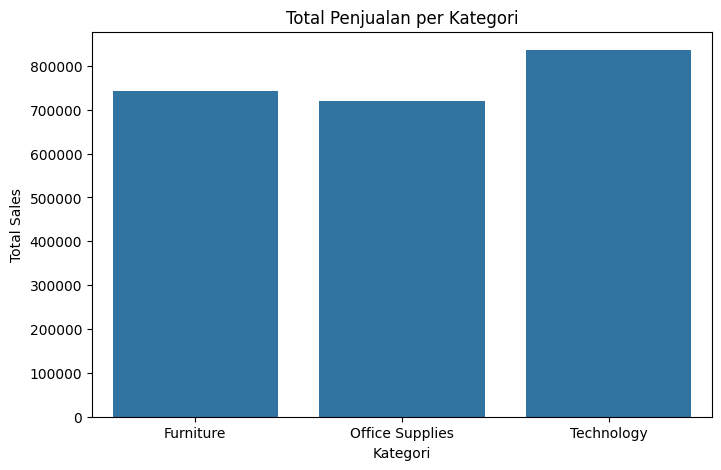

In [20]:
category_sales = df.groupby('Category')['Sales'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Sales', data=category_sales)

plt.title('Total Penjualan per Kategori')
plt.xlabel('Kategori')
plt.ylabel('Total Sales')
plt.show()

# Map — Penjualan Berdasarkan Lokasi

In [21]:
state_sales = df.groupby('State')['Sales'].sum().reset_index()

fig = px.choropleth(
    state_sales,
    locations='State',
    locationmode='USA-states',
    color='Sales',
    scope='usa',
    title='Distribusi Penjualan per State'
)

fig.show()

# Scatter Plot — Sales vs Profit

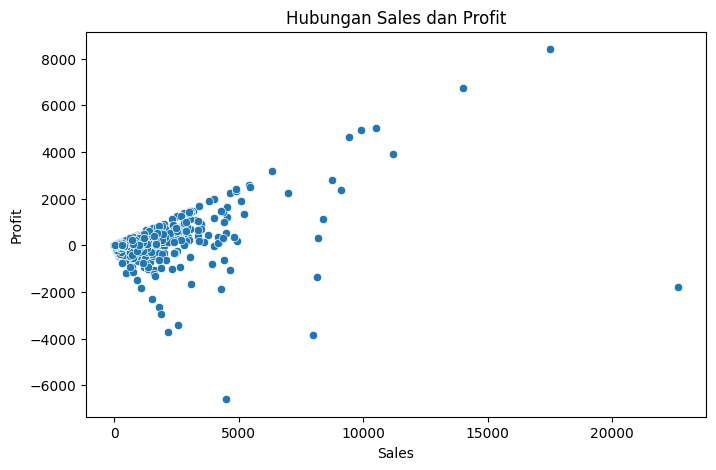

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Sales', y='Profit', data=df)

plt.title('Hubungan Sales dan Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.show()